# Early Popularity Prediction

**Fixes in this version:**
- Incremental graph building (no per-day full rebuild → ~10× faster)
- Vectorised edge extraction and activity features (no `iterrows`)
- Pre-grouped date lookups
- Fixed sequence-creation bug (feature dicts were accidentally stored as tuples)
- `BCEWithLogitsLoss` + `pos_weight` for class-imbalance handling
- `BatchNorm` in MLP for better training stability


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import warnings, os
warnings.filterwarnings('ignore')


## 1. Load Data

In [ ]:

cache_base = os.path.expanduser("~/.cache/huggingface/hub")
SNAPSHOTS = [
    "4ea70791acc3e17bbcbdb168110d71cc2839f85a",
    "4223588375cb422669667ca23e49b5e0acce5043",
    "d4bccc23df0667c2a8a73bc7fe076009fa1dca22",
]

def load_from_cache(name):
    for snap in SNAPSHOTS:
        path = os.path.join(cache_base,
            f"datasets--SimulaMet--moltbook-observatory-archive/snapshots/{snap}/data/{name}")
        if os.path.exists(path) and os.listdir(path):
            files = [f for f in os.listdir(path)
                     if f.endswith('.parquet') and not f.startswith('1970-')]
            dfs = []
            for f in sorted(files):
                try: dfs.append(pd.read_parquet(os.path.join(path, f)))
                except: pass
            if dfs:
                df = pd.concat(dfs, ignore_index=True)
                print(f"  {name}: {len(df):,} rows")
                return df
    print(f"  {name}: no cache, loading from HF...")
    from datasets import load_dataset
    ds = load_dataset('SimulaMet/moltbook-observatory-archive', name,
                      token=HF_TOKEN, streaming=True)
    return pd.DataFrame(list(ds['archive']))

df_agents   = load_from_cache('agents')
df_posts    = load_from_cache('posts')
df_comments = load_from_cache('comments')


  agents: 106,746 rows
  posts: 1,084,831 rows
  comments: 1,113,909 rows


## 2. Preprocess Timestamps

In [ ]:
# Vectorised parsing – much faster than .apply(parse_datetime)
df_posts['created_dt']    = pd.to_datetime(df_posts['created_at'],    utc=True, errors='coerce').dt.tz_convert(None)
df_comments['created_dt'] = pd.to_datetime(df_comments['created_at'], utc=True, errors='coerce').dt.tz_convert(None)

df_posts['date']    = df_posts['created_dt'].dt.date
df_comments['date'] = df_comments['created_dt'].dt.date

# Use dump_date (snapshot date) for agent state tracking, not first_seen_at
df_agents['snap_date'] = pd.to_datetime(df_agents['dump_date'], errors='coerce').dt.date

all_dates = sorted(set(df_posts['date'].dropna()) | set(df_comments['date'].dropna()))
NDAYS = 72
dates = all_dates[:NDAYS]
print(f"{NDAYS} days: {dates[0]}  →  {dates[-1]}")


100 days: 2026-01-28  →  2026-04-09


## 3. Precompute Lookups

In [18]:
# Pre-group posts and comments by date (avoids repeated full-table filter per day)
posts_by_date    = {d: g for d, g in df_posts.groupby('date')}
comments_by_date = {d: g for d, g in df_comments.groupby('date')}

# Edge-creation dicts
post_to_author    = df_posts.set_index('id')['agent_id'].to_dict()
comment_to_agent  = df_comments.set_index('id')['agent_id'].to_dict()

# Cumulative agent state (follower/following counts) per date
df_ag = (df_agents[['id', 'snap_date', 'follower_count', 'following_count']]
           .dropna(subset=['snap_date'])
           .fillna({'follower_count': 0, 'following_count': 0}))
agents_snaps = {d: g.set_index('id') for d, g in df_ag.groupby('snap_date')}

agent_cum = {}          # latest known (fc, fg) per agent
agent_state_by_date = {}
for date in dates:
    if date in agents_snaps:
        snap = agents_snaps[date]
        for aid, row in snap.iterrows():
            agent_cum[aid] = (int(row['follower_count']), int(row['following_count']))
    agent_state_by_date[date] = dict(agent_cum)

print(f"Agent states precomputed for {len(agent_state_by_date)} dates.")
print(f"Agents tracked by day {NDAYS}: {len(agent_cum):,}")


Agent states precomputed for 72 dates.
Agents tracked by day 100: 103,408


## 4. Build Temporal Graphs & Extract Features

In [103]:
G = nx.DiGraph()
all_features = {}

for date in tqdm(dates, desc='Processing days'):
    day_c = comments_by_date.get(date, pd.DataFrame())
    day_p = posts_by_date.get(date, pd.DataFrame())

    # ── Vectorised edge building (add only TODAY's edges) ──────────────
    if len(day_c) > 0:
        vc = day_c[day_c['agent_id'].notna()].copy()
        pids = vc['parent_id']
        vc['target'] = pids.map(comment_to_agent).fillna(pids.map(post_to_author))
        G.add_nodes_from(vc['agent_id'].unique())
        edges = vc[vc['target'].notna() & (vc['agent_id'] != vc['target'])]
        G.add_edges_from(zip(edges['agent_id'], edges['target']))

    if G.number_of_nodes() == 0:
        all_features[date] = {}
        continue

    # ── Graph features (computed ONCE per day) ─────────────────────────
    try:
        pr = nx.pagerank(G, max_iter=100)
    except Exception:
        pr = {n: 0.0 for n in G.nodes()}

    G_u = G.to_undirected()
    cl  = nx.clustering(G_u)

    # ── Activity features (vectorised groupby) ─────────────────────────
    def gb_size(df, col): return df.groupby(col).size().to_dict() if len(df) > 0 else {}
    def gb_sum(df, col, v): return df.groupby(col)[v].sum().to_dict() if len(df) > 0 else {}

    p_cnt = gb_size(day_p, 'agent_id')
    c_cnt = gb_size(day_c, 'agent_id')
    p_k   = gb_sum(day_p, 'agent_id', 'score')
    c_k   = gb_sum(day_c, 'agent_id', 'score')

    state = agent_state_by_date[date]
    active = (
        (set(day_p['agent_id'].dropna()) if len(day_p) > 0 else set()) |
        (set(day_c['agent_id'].dropna()) if len(day_c) > 0 else set()) |
        set(G.nodes())
    )

    all_features[date] = {
        agent: {
            'in_degree':       G.in_degree(agent)  if agent in G else 0,
            'out_degree':      G.out_degree(agent) if agent in G else 0,
            #'total_degree':    G.degree(agent)     if agent in G else 0,
            'clustering':      cl.get(agent, 0.0),
            'pagerank':        pr.get(agent, 0.0),
            #'num_posts':       p_cnt.get(agent, 0),
            #'num_comments':    c_cnt.get(agent, 0),
            'karma_gained':    float(p_k.get(agent, 0)) + float(c_k.get(agent, 0)),
            'follower_count':  state.get(agent, (0, 0))[0],
            #'following_count': state.get(agent, (0, 0))[1],
        }
        for agent in active
    }

print(f"Features computed for {len(all_features)} days")


Processing days: 100%|██████████| 72/72 [01:01<00:00,  1.16it/s]

Features computed for 72 days


## 5. Create Sequences (Prediction Task)

In [133]:
LOOKBACK  = 14   # use first N days as input
TARGET_DAY = 72  # predict popularity at day 30
TOP_K      = 15  # top K% = popular

# FEATURE_COLS = [
#     'in_degree', 'out_degree', 'total_degree', 'clustering', 'pagerank',
#     'num_posts', 'num_comments', 'karma_gained', 'follower_count', 'following_count'
# ]

FEATURE_COLS = [
     'in_degree', 'out_degree', 'clustering', 'pagerank',
     'karma_gained', 'follower_count'
 ]

sdates      = sorted(all_features.keys())
target_date = sdates[min(TARGET_DAY - 1, len(sdates) - 1)]

# Use agent state (all tracked agents) rather than only those active on day 30
day30_state = agent_state_by_date.get(target_date, {})
day30 = {a: fc for a, (fc, _) in day30_state.items() if fc > 0}
threshold = np.percentile(list(day30.values()), 100 - TOP_K)

print(f"Target date: {target_date}")
print(f"Agents w/ >0 followers at day {TARGET_DAY}: {len(day30):,}")
print(f"Popularity threshold (top {TOP_K}%): {threshold:.0f} followers")

seqs, lbls = [], []

for agent, fc30 in tqdm(day30.items(), desc='Building sequences'):
    # BUG FIX: store feature dicts directly (NOT tuples)
    hist = [all_features[d][agent]
            for d in sdates[:LOOKBACK]
            if d in all_features and agent in all_features[d]]
    if len(hist) < 5:
        continue

    seqs.append(np.array([[h.get(c, 0) for c in FEATURE_COLS] for h in hist]).mean(0))
    lbls.append(1 if fc30 >= threshold else 0)

X = np.array(seqs)
y = np.array(lbls)
print(f"Created {len(X)} sequences")
print(f"Class distribution: {Counter(y)}  ({y.mean():.1%} popular)")


Target date: 2026-04-09
Agents w/ >0 followers at day 72: 25,869
Popularity threshold (top 15%): 11 followers


Building sequences: 100%|██████████| 25869/25869 [00:00<00:00, 517163.48it/s]

Created 439 sequences
Class distribution: Counter({np.int64(1): 225, np.int64(0): 214})  (51.3% popular)


## 6. Normalise & Train/Test Split

In [134]:
from sklearn.model_selection import train_test_split

mu, sig = X.mean(0), X.std(0) + 1e-8
X_norm  = (X - mu) / sig

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train class dist: {Counter(y_train)}")
print(f"Test  class dist: {Counter(y_test)}")


Train: 351, Test: 88
Train class dist: Counter({np.int64(1): 180, np.int64(0): 171})
Test  class dist: Counter({np.int64(1): 45, np.int64(0): 43})


## 7. Model

In [145]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

class PopularityMLP(nn.Module):
    def __init__(self, n_in, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.BatchNorm1d(hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = PopularityMLP(len(FEATURE_COLS)).to(device)
print(model)


Device: cpu
PopularityMLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 8. Train

pos_weight: 0.95  (balances 171 negatives vs 180 positives)
Epoch   0: train=0.6782  val=0.6868
Epoch  10: train=0.5028  val=0.5400
Epoch  20: train=0.4132  val=0.4686
Epoch  30: train=0.3866  val=0.4036
Epoch  40: train=0.3648  val=0.3551
Epoch  50: train=0.3211  val=0.3238
Epoch  60: train=0.2814  val=0.3117
Epoch  70: train=0.2831  val=0.2794
Epoch  80: train=0.2479  val=0.2618
Epoch  90: train=0.2888  val=0.2546
Epoch 100: train=0.2506  val=0.2385
Epoch 110: train=0.2613  val=0.2423
Early stop at epoch 115


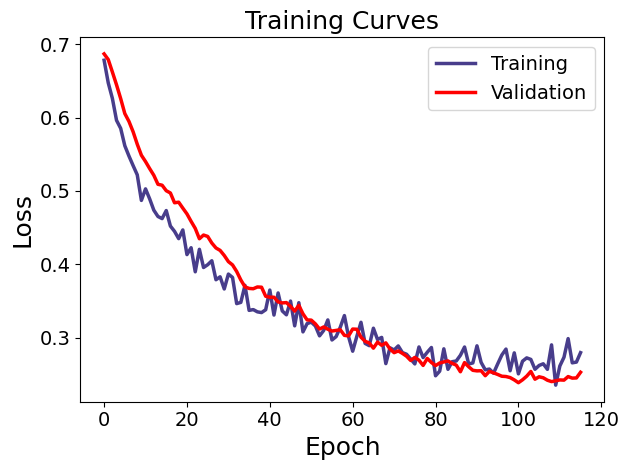

In [146]:
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f'pos_weight: {pos_weight.item():.2f}  (balances {n_neg} negatives vs {n_pos} positives)')

Xtr = torch.FloatTensor(X_train); ytr = torch.FloatTensor(y_train)
Xte = torch.FloatTensor(X_test);  yte = torch.FloatTensor(y_test)

train_dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
test_dl  = DataLoader(TensorDataset(Xte, yte), batch_size=64)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt       = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

best_val, patience_cnt = float('inf'), 0
train_losses, val_losses = [], []

for epoch in range(200):
    model.train()
    tl = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); opt.step()
        tl += loss.item()
    tl /= len(train_dl)

    model.eval()
    with torch.no_grad():
        vl = sum(criterion(model(xb.to(device)), yb.to(device)).item()
                 for xb, yb in test_dl) / len(test_dl)

    train_losses.append(tl); val_losses.append(vl)
    sched.step(vl)

    if vl < best_val:
        best_val, patience_cnt = vl, 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_cnt += 1

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}: train={tl:.4f}  val={vl:.4f}')

    if patience_cnt >= 15:
        print(f'Early stop at epoch {epoch}'); break

plt.figure()
plt.plot(train_losses, label='Training', color='darkslateblue',lw=2.5); plt.plot(val_losses, label='Validation',color='red',lw=2.5)
plt.xlabel('Epoch',fontsize=18); plt.ylabel('Loss',fontsize=18); plt.legend(fontsize=14); plt.grid(False); plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.title('Training Curves',fontsize=18); plt.tight_layout(); plt.show()


## 9. Evaluate

Accuracy:  0.9205
Precision: 0.8800
Recall:    0.9778
F1:        0.9263
AUC-ROC:   0.9928

Confusion Matrix:
[[37  6]
 [ 1 44]]


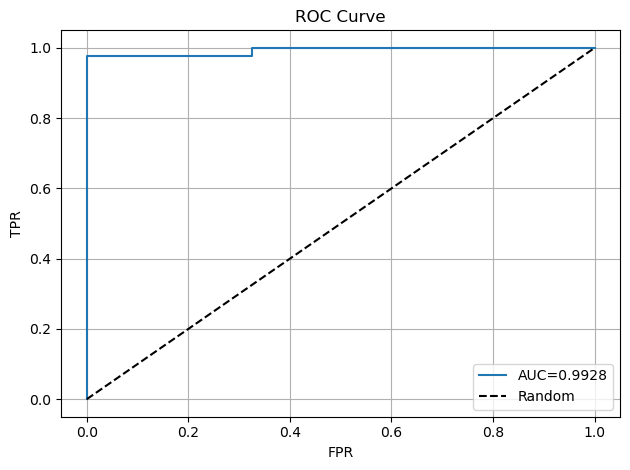

In [147]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    logits = model(Xte.to(device)).cpu().numpy()

probs = 1 / (1 + np.exp(-logits))   # sigmoid
preds = (probs >= 0.5).astype(int)

acc   = accuracy_score(y_test, preds)
prec  = precision_score(y_test, preds, zero_division=0)
rec   = recall_score(y_test, preds, zero_division=0)
f1    = f1_score(y_test, preds, zero_division=0)
auc   = roc_auc_score(y_test, probs)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1:        {f1:.4f}')
print(f'AUC-ROC:   {auc:.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, preds)}')

fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


## 10. Baseline Comparison

In [148]:
rnd = (np.random.rand(len(y_test)) >= 0.5).astype(int)
maj = np.zeros(len(y_test), dtype=int)

print('Baseline Comparison')
print(f'  Random   Acc={accuracy_score(y_test, rnd):.4f}  F1={f1_score(y_test, rnd):.4f}')
print(f'  Majority Acc={accuracy_score(y_test, maj):.4f}  F1={f1_score(y_test, maj):.4f}')
print(f'  Model    Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')


Baseline Comparison
  Random   Acc=0.5000  F1=0.5111
  Majority Acc=0.4886  F1=0.0000
  Model    Acc=0.9205  F1=0.9263  AUC=0.9928
